In [1]:
import os
if os.getcwd().endswith('scripts'):
    os.chdir('..')
print(f"Current working directory: {os.getcwd()}")

Current working directory: c:\Users\YuMeow\WorkSpace\35-HuaweiCrowdSimulation\HuaweiCrowdSimulationCode


In [2]:
import json
import torch
import random
import logging
import numpy as np
import torch.utils.data as D
from tqdm import tqdm
from pathlib import Path
from datetime import datetime
from argparse import Namespace
from socket import gethostname
from setproctitle import setproctitle
from src.dataset import ETHDataset, UCYDataset, SDDDataset
from src.model.model import Model
from src.diffusion import DDPM, DDIM
from src.utils.logger import init_logger
from src.utils.seed import seed_all

init_logger('src')

args = Namespace(
    name="DDPM",
    device="cuda:0",
    batch_size=256,
    lr=1e-3,
    epochs=10000,
    T=100,
    hist_step=8,
    pred_step=12,
    skip_step=1,
    fps=2.5,
    dot_per_meter=5,
    seed=None,
    save_dir="./logs/train",
    debug=False,
    model_dim=256,
    map_feature_dim=64,
    head_num=4,
    dropout=0.1,
    latent_token_num=16,
    beta_schedule='linear',
    num_workers=0,
    cache_dataset=True,
    test_before_train=False,
)

In [3]:
args.cache_dataset = False
ETHDataset.load_data(args, "./data/ETH/seq_eth/obsmat.txt")
args.cache_dataset = True

[None|base_dataset|I|Oct06 22:12:12|0:00:07.658792] Normalized x with mean=5.2178, std=1.0000
[None|base_dataset|I|Oct06 22:12:12|0:00:07.659789] Normalized y with mean=5.3164, std=1.0000
[None|base_dataset|I|Oct06 22:12:12|0:00:07.660790] Normalized map into xmin=-15.3125, xmax=9.4626, ymin=-16.2576, ymax=15.8446
[None|base_dataset|I|Oct06 22:12:12|0:00:07.659789] Normalized y with mean=5.3164, std=1.0000
[None|base_dataset|I|Oct06 22:12:12|0:00:07.660790] Normalized map into xmin=-15.3125, xmax=9.4626, ymin=-16.2576, ymax=15.8446
[None|eth_dataset|I|Oct06 22:14:10|0:02:05.183323] Caching dataset to data\.cache\eth_2.5_8_12_1.pkl


In [4]:
# Load Dataset
dataset_list = [
    # SDDDataset.load_data(args, "./data/SDD/annotations/bookstore/video1/annotations.txt"),
    # SDDDataset.load_data(args, "./data/SDD/annotations/bookstore/video2/annotations.txt"),
    *UCYDataset.load_data_batch(args, "./data/UCY/data/"),
    *ETHDataset.load_data_batch(args, "./data/ETH/"),
]


Loading ETH datasets: 100%|██████████| 2/2 [00:05<00:00,  2.96s/it, seq_hotel]


C:\Users\YuMeow\AppData\Local\Temp\ipykernel_32984\2945061695.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis')


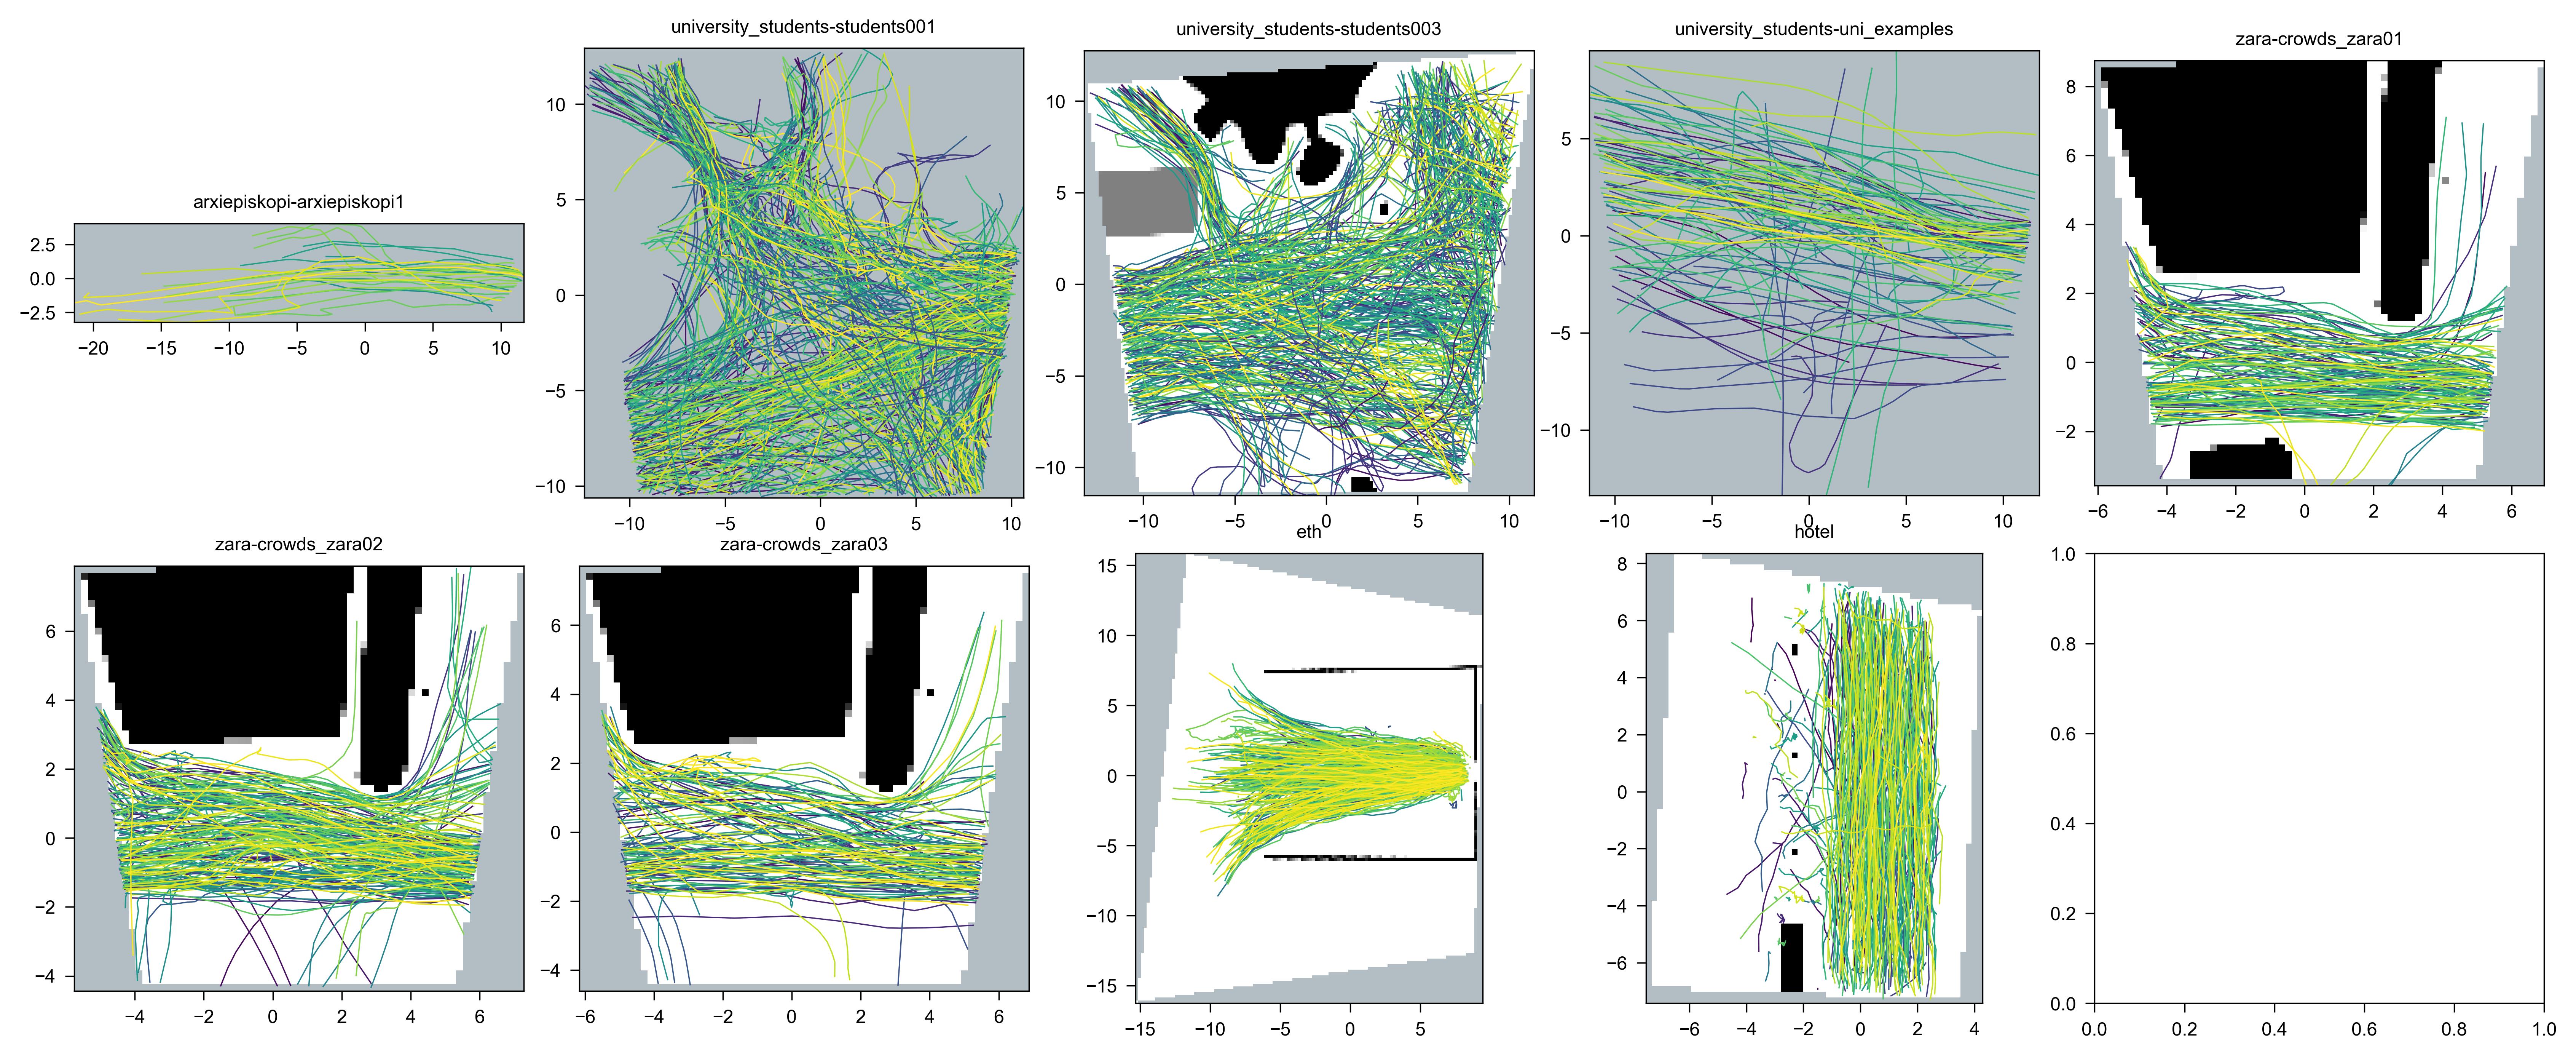

In [5]:
import matplotlib.pyplot as plt
from src.utils.plot import get_fig

fi, fig, axes = get_fig(2, 5, AW=6, AH=6, dpi=500)
cmap = plt.cm.get_cmap('viridis')

for idx, dataset in enumerate(dataset_list):
    ax = axes[idx]
    df_data = dataset.df_data
    map_data = dataset.map_data
    for id, group in df_data.groupby('id'):
        ax.plot(group['x'], group['y'], color=cmap(group['f'].max() / df_data['f'].max()))
    ax.imshow(map_data.map, cmap='gray_r', origin='lower', extent=(map_data.xmin, map_data.xmax, map_data.ymin, map_data.ymax))
    ax.set_title(dataset.name)
    ax.set_aspect('equal')
    ax.set_facecolor('#b2bec3')